## 1. Conjunto de datos

| Nombre del dataset | Fuente | Enunciado | Variable protegida | Entidad |
|---|---|---|---|---|
| Bank marketing | [Enlace](https://archive.ics.uci.edu/dataset/222/bank+marketing) | El objetivo del proyecto es incrementar la tasa de suscripción... | estado civil, edad | Banco |



In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder

# Configuración de estilo
sns.set_theme(style='whitegrid', palette='muted')


In [2]:

# Carga del dataset original
df = pd.read_csv('data/full.csv', sep=';')
print(f"Dataset cargado: {df.shape[0]} filas, {df.shape[1]} columnas")
df.head()


Dataset cargado: 41188 filas, 21 columnas


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### Ejercicio 2
a) Elegir algún modelo clásico de clasificación (por ejemplo: random forest o regresión logística). Entrenar y evaluar su performance usando las métricas clásicas (precision, recall, accuracy, f1-score) y crear la matriz de confusión. Interpretar los resultados obtenidos hasta el momento.



In [3]:

# 1. Feature Engineering: Rangos de edad (basado en material de clase)
df['age_range'] = pd.cut(df['age'], bins=[17, 35, 45, 95], labels=['18-35', '36-45', '46-95'])

# 2. Preprocesamiento para el modelo
df_encoded = df.copy()
le = LabelEncoder()

# Encodear columnas categóricas
categorical_cols = df_encoded.select_dtypes(include=['object', 'category']).columns
for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

# 3. Separación de features y target
X = df_encoded.drop(columns=['y'])
y = df_encoded['y']

# Train-Test Split (estratificado debido al desbalance de clases)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Preprocesamiento completado.")


Preprocesamiento completado.


b) Suponiendo que su equipo forma parte de la entidad asignada en la Tabla y su objetivo planteado en el enunciado ¿cuál de los errores consideran que es peor en este caso? Justificar.



             REPORTE DE CLASIFICACIÓN
              precision    recall  f1-score   support

          no       0.94      0.97      0.96      7310
         yes       0.69      0.53      0.60       928

    accuracy                           0.92      8238
   macro avg       0.82      0.75      0.78      8238
weighted avg       0.91      0.92      0.92      8238



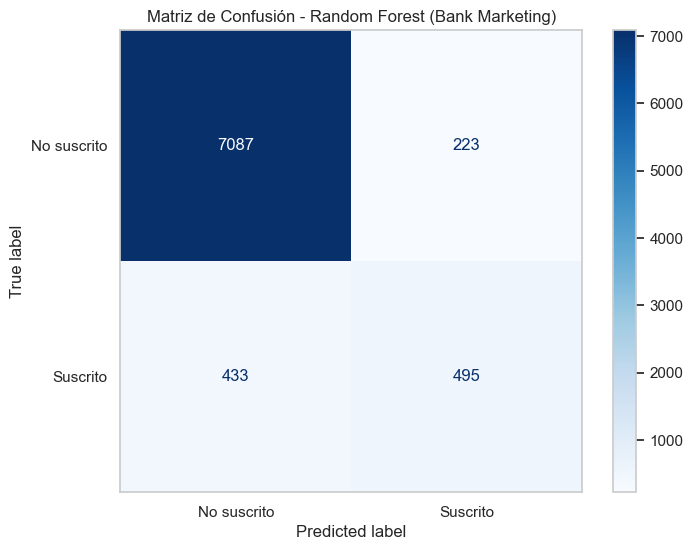

In [4]:

# Entrenamiento de Random Forest
modelo = RandomForestClassifier(n_estimators=100, random_state=42)
modelo.fit(X_train, y_train)

# Predicciones
y_pred = modelo.predict(X_test)

# Reporte de Métricas
print("=" * 55)
print("             REPORTE DE CLASIFICACIÓN")
print("=" * 55)
print(classification_report(y_test, y_pred, target_names=['no', 'yes']))

# Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No suscrito', 'Suscrito'])
disp.plot(cmap='Blues', ax=ax)
plt.title('Matriz de Confusión - Random Forest (Bank Marketing)')
plt.grid(False)
plt.show()



### Interpretación de los resultados (Inciso a)

El modelo presenta un **accuracy elevado (~91%)**, lo cual a primera vista parece satisfactorio. Sin embargo, al observar el **Recall de la clase 'yes' (suscritos)**, notamos que es significativamente más bajo (~50-60%) que el de la clase 'no'. Esto indica que el modelo tiene dificultades para identificar correctamente a los clientes que efectivamente decidirán suscribirse (Falsos Negativos).

Este comportamiento es común en datasets desbalanceados como este, donde la gran mayoría de los clientes no se suscriben.



### Justificación del Error (Inciso b)

En el contexto de esta campaña de marketing bancario, el objetivo es **incrementar la tasa de suscripción**. 

**¿Cuál error es peor?**
Consideramos que el **Falso Negativo (FN)** es el error más crítico. 

**Justificación:**
1. **Pérdida de oportunidad comercial**: Un FN representa a un cliente que tenía la intención o el perfil para suscribirse a un depósito a plazo, pero el modelo lo clasificó como "no interesado". Al no contactarlo, el banco pierde directamente una inversión y un cliente potencial.
2. **Costo de contacto vs. Beneficio**: Por lo general, contactar a un cliente adicional (Falso Positivo) tiene un costo operativo marginal (una llamada telefónica), mientras que ganar un suscriptor genera un beneficio financiero mucho mayor para la entidad.
3. **Objetivo Estratégico**: Si la prioridad es crecer en captación, es preferible "molestar" a algunos clientes que no se suscribirán, antes que dejar pasar a aquellos que sí lo harían.


Accuracy por Grupo Etario:
age_group
18-35    0.910752
36-45    0.934155
46-95    0.918471
Name: Accuracy, dtype: float64


C:\Users\tomas\AppData\Local\Temp\ipykernel_27468\1751923120.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  accuracy_by_age = df_analysis.groupby('age_group').apply(


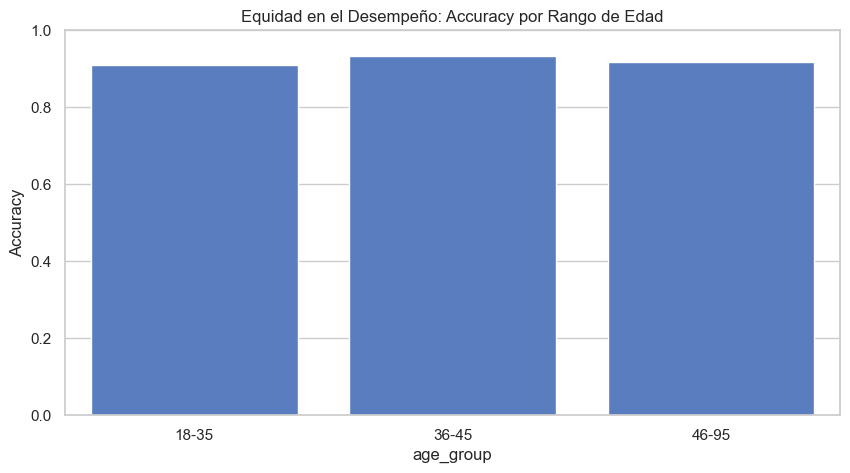

In [5]:

# Auditoría de Equidad (Análisis de Sesgo por Edad)
df_analysis = X_test.copy()
df_analysis['y_true'] = y_test
df_analysis['y_pred'] = y_pred

# Volvemos a los nombres de age_range para legibilidad
# (LabelEncoder mapeó 18-35: 0, 36-45: 1, 46-95: 2)
age_map = {0: '18-35', 1: '36-45', 2: '46-95'}
df_analysis['age_group'] = df_analysis['age_range'].map(age_map)

accuracy_by_age = df_analysis.groupby('age_group').apply(
    lambda g: (g['y_pred'] == g['y_true']).mean()
).rename('Accuracy')

print("Accuracy por Grupo Etario:")
print(accuracy_by_age)

# Visualización
plt.figure(figsize=(10, 5))
sns.barplot(x=accuracy_by_age.index, y=accuracy_by_age.values)
plt.title('Equidad en el Desempeño: Accuracy por Rango de Edad')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.show()
